---
# COSC2753 | Machine Learning

## Task 0: Data Audit and Exploratory Data Analysis
---

# 1. Introduction

This notebook creates the shared evidence and data contract for every model. It audits metadata and images, detects exact duplicates, studies imbalance and target relationships, creates one group-isolated frozen split, and computes training-only RGB statistics. Run and review it before Tasks 1–4.

# 2. Library Imports and Setup

In [1]:
from pathlib import Path
import hashlib, json, os, sys

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'scripts'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image, UnidentifiedImageError
from sklearn.model_selection import GroupShuffleSplit

from preprocessing import (
    IMAGE_AUDIT_PATH, IMAGE_SIZE, NORMALISATION_PATH, OUTPUT_DIR, SEED, SPLIT_PATH, TARGETS,
    load_metadata, load_prediction_template, preprocess_image,
)
sns.set_theme(style='whitegrid')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 3. Metadata and Coverage Audit

In [2]:
metadata = load_metadata()
template = load_prediction_template()
coverage_report = {
    'training_rows': len(metadata),
    'training_images_found': int(metadata.has_image.sum()),
    'missing_training_ids': metadata.loc[~metadata.has_image, 'id'].tolist(),
    'test_rows': len(template),
    'missing_test_ids': template.loc[~template.image_path.map(lambda value: Path(value).is_file()), 'id'].tolist(),
    'blank_labels': {target: int(metadata[target].str.strip().eq('').sum()) for target in TARGETS},
}
coverage_report

{'training_rows': 38617,
 'training_images_found': 38612,
 'missing_training_ids': ['12347', '39401', '39403', '39410', '39425'],
 'test_rows': 5829,
 'missing_test_ids': [],
 'blank_labels': {'articleType': 0, 'season': 20, 'gender': 0, 'usage': 1}}

Literal `NA` usage values are preserved because the shared loader disables automatic missing-value conversion. A genuinely blank label is removed only in that target's modelling notebook. Investigate and document every missing image ID.

# 4. Full Decode and SHA-256 Audit

This pass reads every image and can be slow. It runs automatically when the cached image audit is missing. Set `FASHION_RUN_FULL_AUDIT=1` to repeat it, or use `--force-audit` with the notebook runner.

In [3]:
audit_setting = os.environ.get('FASHION_RUN_FULL_AUDIT', 'auto').strip().lower()
RUN_FULL_AUDIT = audit_setting in {'1', 'true', 'yes'} or (audit_setting == 'auto' and not IMAGE_AUDIT_PATH.exists())
if RUN_FULL_AUDIT:
    image_rows = []
    for row in metadata.loc[metadata.has_image].itertuples(index=False):
        try:
            digest = hashlib.sha256()
            with Path(row.image_path).open('rb') as handle:
                for chunk in iter(lambda: handle.read(1024 * 1024), b''):
                    digest.update(chunk)
            with Image.open(row.image_path) as image:
                image.load()
                image_rows.append({
                    'id': row.id, 'sha256': digest.hexdigest(), 'width': image.width,
                    'height': image.height, 'mode': image.mode, 'decode_error': '',
                })
        except (OSError, UnidentifiedImageError) as error:
            image_rows.append({
                'id': row.id, 'sha256': '', 'width': '', 'height': '', 'mode': '',
                'decode_error': type(error).__name__,
            })
    image_audit = pd.DataFrame(image_rows)
    image_audit.to_csv(IMAGE_AUDIT_PATH, index=False)
else:
    print(f'Using cached image audit: {IMAGE_AUDIT_PATH}')

Using cached image audit: D:\khoile\programs\fashion-intelligence-classification\scripts\data\image_audit.csv


In [4]:
if IMAGE_AUDIT_PATH.exists():
    image_audit = pd.read_csv(IMAGE_AUDIT_PATH, dtype={'id': 'string'}, keep_default_na=False)
    hashes = image_audit.loc[image_audit.sha256.ne(''), 'sha256'].value_counts()
    audit_report = {
        **coverage_report,
        'decoded_images': int(image_audit.decode_error.eq('').sum()),
        'decode_errors': image_audit.loc[image_audit.decode_error.ne(''), 'id'].tolist(),
        'exact_duplicate_hash_groups': int(hashes.gt(1).sum()),
        'image_modes': image_audit['mode'].value_counts().to_dict(),
    }
    (OUTPUT_DIR / 'audit.json').write_text(json.dumps(audit_report, indent=2), encoding='utf-8')
    display(audit_report)
else:
    image_audit = None

{'training_rows': 38617,
 'training_images_found': 38612,
 'missing_training_ids': ['12347', '39401', '39403', '39410', '39425'],
 'test_rows': 5829,
 'missing_test_ids': [],
 'blank_labels': {'articleType': 0, 'season': 20, 'gender': 0, 'usage': 1},
 'decoded_images': 38611,
 'decode_errors': ['8121'],
 'exact_duplicate_hash_groups': 636,
 'image_modes': {'RGB': 38268, 'L': 343, '': 1}}

# 5. Target Distributions and Missing Labels

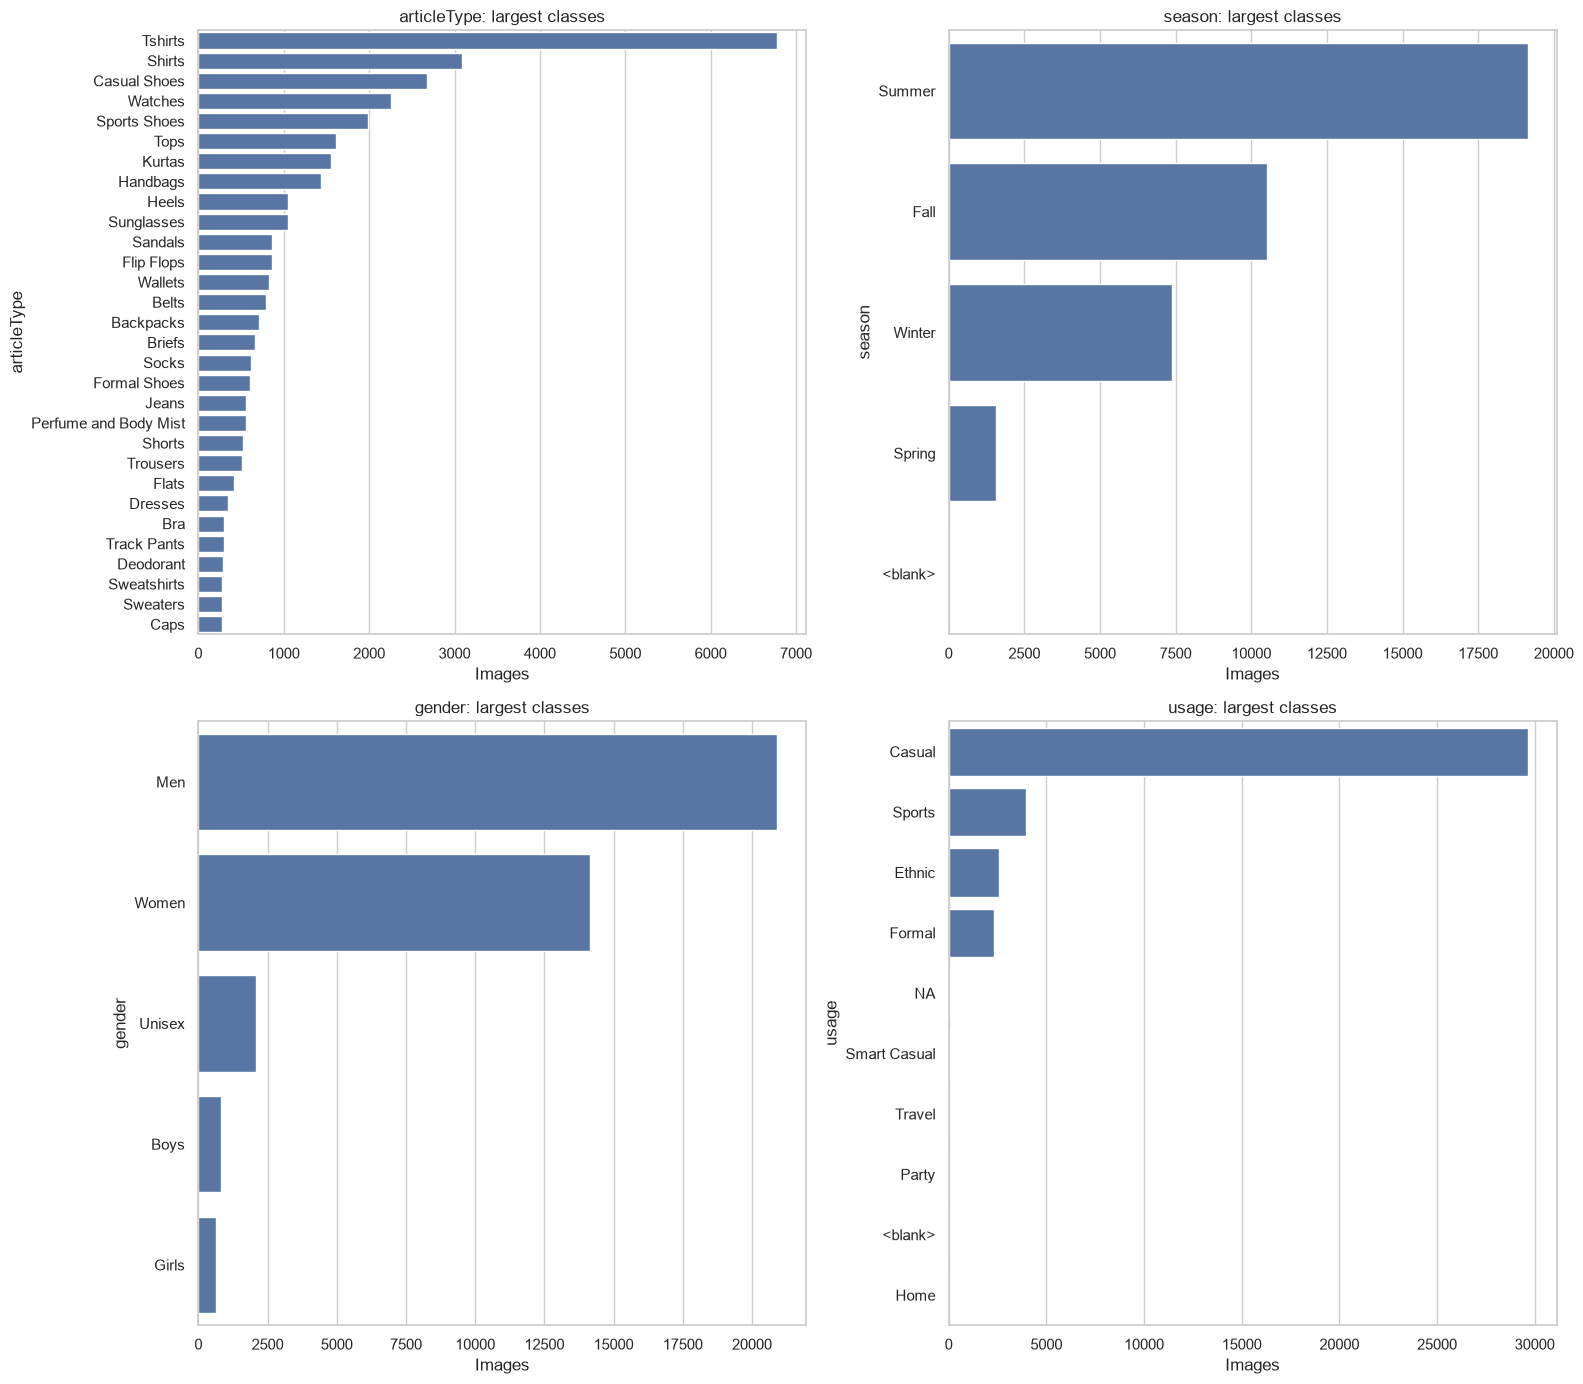

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
for target, axis in zip(TARGETS, axes.ravel()):
    counts = metadata[target].replace('', '<blank>').value_counts().head(30)
    sns.barplot(x=counts.values, y=counts.index, ax=axis)
    axis.set_title(f'{target}: largest classes')
    axis.set_xlabel('Images')
plt.tight_layout()

In [6]:
distribution_summary = pd.DataFrame({
    target: {
        'classes': metadata.loc[metadata[target].str.strip().ne(''), target].nunique(),
        'blank': metadata[target].str.strip().eq('').sum(),
        'largest_class_share': metadata[target].value_counts(normalize=True).iloc[0],
        'classes_below_10': int((metadata[target].value_counts() < 10).sum()),
    } for target in TARGETS
}).T
distribution_summary

,classes,blank,largest_class_share,classes_below_10
articleType,125.0,0.0,0.175596,33.0
season,4.0,20.0,0.495559,0.0
gender,5.0,0.0,0.541679,0.0
usage,9.0,1.0,0.767564,2.0


## 5.1 Distribution observations

Discuss dominant and rare labels for every target. This evidence motivates macro F1 as the main classifier metric. For article type, define head/medium/tail support. For usage, distinguish one genuinely blank value from literal `NA`.

# 6. Target Relationships and Confounding

In [7]:
pd.crosstab(metadata.articleType, metadata.season, normalize='index').head(25).style.background_gradient(cmap='Blues')

season,,Fall,Spring,Summer,Winter
articleType,,,,,
Accessory Gift Set,0.000000,0.462264,0.000000,0.150943,0.386792
Baby Dolls,0.000000,0.000000,0.000000,1.000000,0.000000
Backpacks,0.000000,0.185915,0.063380,0.485915,0.264789
Bangle,0.000000,0.120690,0.017241,0.724138,0.137931
Basketballs,0.000000,0.230769,0.000000,0.615385,0.153846
Belts,0.000000,0.122013,0.021384,0.660377,0.196226
Blazers,0.000000,0.000000,0.000000,1.000000,0.000000
Body Wash and Scrub,0.000000,0.000000,1.000000,0.000000,0.000000
Booties,0.000000,0.000000,0.000000,1.000000,0.000000


In [8]:
pd.crosstab(metadata.gender, metadata.usage, normalize='index').style.background_gradient(cmap='Purples')

usage,,Casual,Ethnic,Formal,Home,NA,Party,Smart Casual,Sports,Travel
gender,,,,,,,,,,
Boys,0.000000,0.961916,0.012285,0.000000,0.000000,0.000000,0.000000,0.000000,0.025799,0.000000
Girls,0.000000,0.984496,0.012403,0.000000,0.000000,0.000000,0.000000,0.000000,0.003101,0.000000
Men,0.000048,0.750120,0.004303,0.104838,0.000000,0.001052,0.000000,0.002103,0.137489,0.000048
Unisex,0.000000,0.845192,0.000000,0.000481,0.000481,0.008654,0.000000,0.000000,0.135577,0.009615
Women,0.000000,0.760876,0.173870,0.007486,0.000000,0.002189,0.000918,0.000777,0.053602,0.000282


Explain where season, usage, or gender may be predicted through article-type shortcuts rather than direct visual evidence.

# 7. Visual Inspection

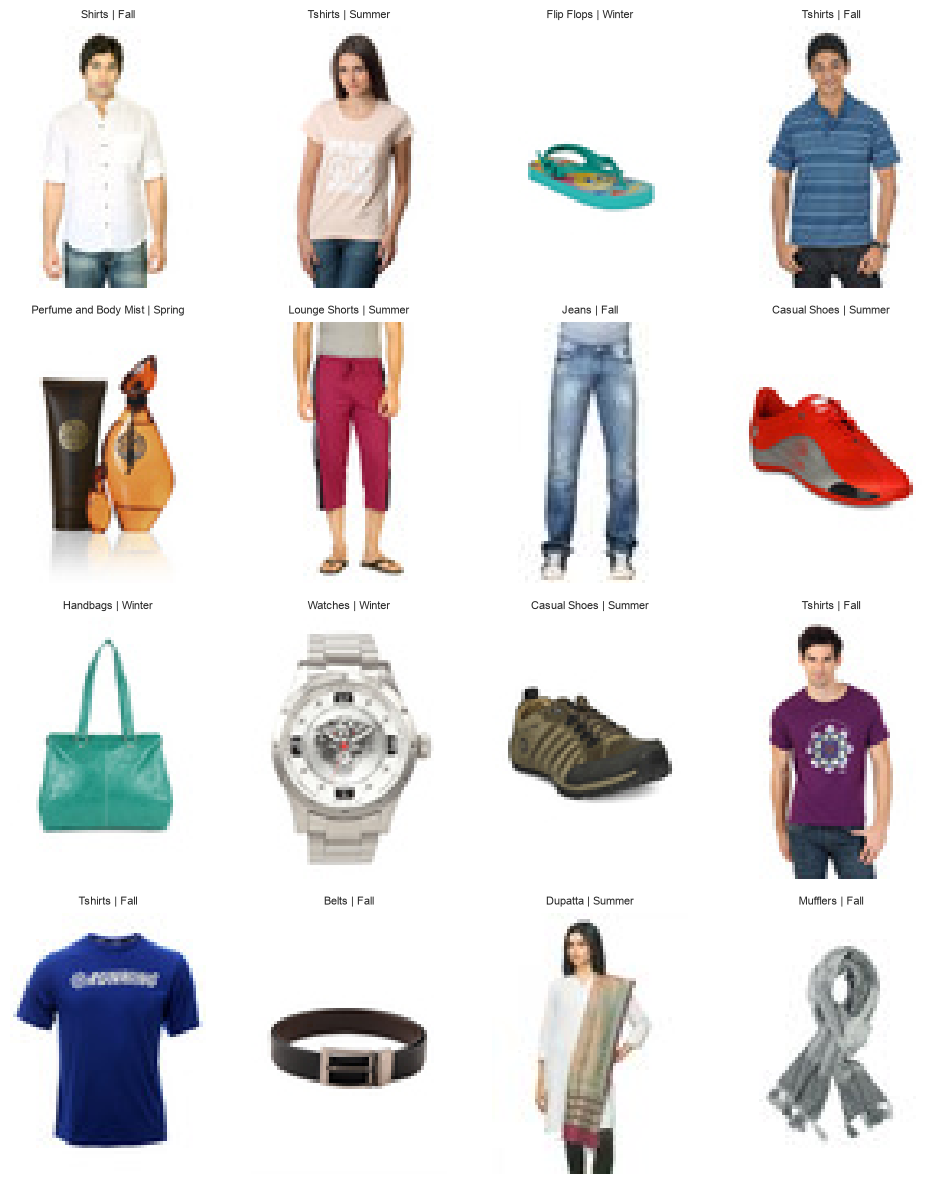

In [9]:
sample = metadata.loc[metadata.has_image].sample(16, random_state=SEED)
fig, axes = plt.subplots(4, 4, figsize=(10, 12))
for (_, row), axis in zip(sample.iterrows(), axes.ravel()):
    with Image.open(row.image_path) as image:
        axis.imshow(image.convert('RGB'))
    axis.set_title(f'{row.articleType} | {row.season}', fontsize=8)
    axis.axis('off')
plt.tight_layout()

In [10]:
if image_audit is not None:
    display(image_audit[['width', 'height']].describe())
    display(image_audit['mode'].value_counts())

,width,height
count,38612,38612
unique,3,6
top,60,80
freq,38603,38602


mode
RGB    38268
L        343
           1
Name: count, dtype: int64

# 8. Duplicate-Safe Frozen Split

The following code joins rows that share a normalized product display name or exact SHA-256 hash, then assigns whole connected groups to deterministic 70/15/15 splits.

In [11]:
def build_group_keys(frame, audit):
    frame = frame.merge(audit[['id', 'sha256', 'decode_error']], on='id', how='left')
    frame = frame.loc[frame.has_image & frame.decode_error.eq('')].reset_index(drop=True)
    frame['name_key'] = frame.productDisplayName.astype('string').str.lower().str.replace(r'\W+', ' ', regex=True).str.strip()
    frame.loc[frame.name_key.eq(''), 'name_key'] = frame.id
    parent = list(range(len(frame)))
    def find(index):
        while parent[index] != index:
            parent[index] = parent[parent[index]]; index = parent[index]
        return index
    def union(left, right):
        left_root, right_root = find(left), find(right)
        if left_root != right_root: parent[right_root] = left_root
    for column in ('name_key', 'sha256'):
        values = frame[column].astype('string').fillna('')
        for value, indices in values.groupby(values, sort=False).groups.items():
            if not value or len(indices) < 2: continue
            first = int(indices[0])
            for index in indices[1:]: union(first, int(index))
    frame['group_key'] = [f'group_{find(index)}' for index in range(len(frame))]
    return frame

def create_frozen_split(frame, audit):
    grouped = build_group_keys(frame, audit)
    first = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=SEED)
    _, holdout_index = next(first.split(grouped, groups=grouped.group_key))
    holdout = grouped.iloc[holdout_index]
    second = GroupShuffleSplit(n_splits=1, train_size=0.50, random_state=SEED + 1)
    _, test_relative = next(second.split(holdout, groups=holdout.group_key))
    grouped['split'] = 'train'
    grouped.loc[grouped.id.isin(holdout.id), 'split'] = 'validation'
    grouped.loc[grouped.id.isin(holdout.iloc[test_relative].id), 'split'] = 'test'
    return grouped[['id', 'group_key', 'split']]

def enforce_training_label_coverage(frame, split_frame):
    """Move whole duplicate groups to train when a label has no train example."""
    revised = split_frame.copy()
    changes = []
    for target in TARGETS:
        joined = frame[['id', target]].merge(revised, on='id', validate='one_to_one')
        valid = joined[target].astype('string').str.strip().ne('')
        train_labels = set(joined.loc[valid & joined.split.eq('train'), target])
        missing_labels = sorted(set(joined.loc[valid, target]) - train_labels)
        for label in missing_labels:
            groups = joined.loc[valid & joined[target].eq(label), 'group_key'].unique()
            move_mask = revised.group_key.isin(groups) & ~revised.split.eq('train')
            changes.append({
                'target': target, 'label': label,
                'groups_moved': int(len(groups)), 'rows_moved': int(move_mask.sum()),
            })
            revised.loc[revised.group_key.isin(groups), 'split'] = 'train'
    return revised, pd.DataFrame(changes)

if SPLIT_PATH.exists():
    splits = pd.read_csv(SPLIT_PATH, dtype={'id': 'string'})
elif image_audit is None:
    raise RuntimeError('Complete the full image audit before creating splits')
else:
    splits = create_frozen_split(metadata, image_audit)
splits, coverage_repairs = enforce_training_label_coverage(metadata, splits)
splits.to_csv(SPLIT_PATH, index=False)
if not coverage_repairs.empty:
    display(coverage_repairs)
splits['split'].value_counts(), splits.groupby('group_key')['split'].nunique().max()

(split
 train         27051
 validation     5842
 test           5718
 Name: count, dtype: int64,
 np.int64(1))

In [12]:
split_metadata = metadata.merge(splits, on='id', validate='one_to_one')
pd.concat(
    {target: pd.crosstab(split_metadata[target], split_metadata.split, normalize='columns') for target in TARGETS},
    names=['target', 'label'],
).head(40)

split                                  test     train  validation
target      label                                                
articleType Accessory Gift Set     0.003148  0.002403    0.003937
            Baby Dolls             0.000000  0.000074    0.000000
            Backpacks              0.019237  0.017929    0.019685
            Bangle                 0.000350  0.001479    0.002739
            Basketballs            0.000175  0.000333    0.000514
            Belts                  0.023085  0.020886    0.016604
            Blazers                0.000525  0.000148    0.000171
            Body Wash and Scrub    0.000000  0.000037    0.000000
            Booties                0.000350  0.000222    0.000685
            Boxers                 0.000874  0.000998    0.001198
            Bra                    0.005421  0.007874    0.009072
            Bracelet               0.000175  0.001072    0.003595
            Briefs                 0.018538  0.016968    0.017631
            Camisoles              0.000175  0.000518    0.000000
            Capris                 0.004547  0.004029    0.004451
            Caps                   0.007345  0.006839    0.008045
            Casual Shoes           0.076600  0.069498    0.062479
            Churidar               0.000350  0.000850    0.000856
            Clothing Set           0.000175  0.000148    0.000514
            Clutches               0.004547  0.006210    0.004964
            Compact                0.000175  0.000111    0.000000
            Concealer              0.000000  0.000074    0.000000
            Cufflinks              0.000700  0.001257    0.001027
            Cushion Covers         0.000000  0.000037    0.000000
            Deodorant              0.005946  0.008022    0.007189
            Dresses                0.010143  0.008687    0.008901
            Duffel Bag             0.003148  0.001959    0.002568
            Dupatta                0.003673  0.002994    0.002396
            Earrings               0.002798  0.005360    0.014379
            Eyeshadow              0.000000  0.000111    0.000342
            Flats                  0.006995  0.011682    0.010613
            Flip Flops             0.020637  0.022439    0.023622
            Footballs              0.000175  0.000222    0.000171
            Formal Shoes           0.019937  0.014898    0.015919
            Foundation and Primer  0.000525  0.000296    0.000171
            Fragrance Gift Set     0.001224  0.001220    0.002568
            Free Gifts             0.001049  0.001959    0.001712
            Gloves                 0.000525  0.000481    0.000685
            Handbags               0.032529  0.039888    0.029784
            Hat                    0.000000  0.000111    0.000000

Review split sizes, label proportions, unsupported classes, and confirm that no `group_key` crosses splits. Once modelling begins, do not regenerate this file.

# 9. Training-Only RGB Normalization

In [13]:
def compute_training_normalisation(frame, split_frame):
    joined = frame.merge(split_frame, on='id', validate='one_to_one')
    paths = joined.loc[joined.split.eq('train'), 'image_path']
    channel_sum = np.zeros(3, dtype=np.float64)
    channel_square_sum = np.zeros(3, dtype=np.float64)
    pixel_count = 0
    for path in paths:
        with Image.open(path) as image:
            array = np.transpose(preprocess_image(image), (1, 2, 0)).astype(np.float64)
        channel_sum += array.sum(axis=(0, 1))
        channel_square_sum += np.square(array).sum(axis=(0, 1))
        pixel_count += array.shape[0] * array.shape[1]
    mean = channel_sum / pixel_count
    std = np.sqrt(channel_square_sum / pixel_count - np.square(mean))
    return {'mean': mean.tolist(), 'std': std.tolist(), 'image_size': list(IMAGE_SIZE)}

if NORMALISATION_PATH.exists():
    with NORMALISATION_PATH.open(encoding='utf-8') as handle:
        normalisation = json.load(handle)
else:
    normalisation = compute_training_normalisation(metadata, splits)
    NORMALISATION_PATH.write_text(json.dumps(normalisation, indent=2), encoding='utf-8')
normalisation

{'mean': [0.8502750031713799, 0.8334922756826109, 0.8277549238925582],
 'std': [0.26589262549701936, 0.2775687167185324, 0.28121521485116663],
 'image_size': [96, 128]}

# 10. Decisions and Limitations

Replace this prompt with evidence-backed decisions: RGB conversion, 128×96 resize, exact/name group isolation, 70/15/15 split, training-only normalization and augmentation, macro-F1 selection, blank-label handling, literal-`NA` policy, and limits of visually inferring season, usage, or gender.